In [29]:
import pandas as pd
import numpy  as np
from pathlib import Path
import matplotlib.pyplot as plt
import pypsa
import yaml

In [33]:
with open(
    Path.cwd().parent / 'config.basicrun.yaml'
) as f:
    config = yaml.safe_load(f)
model_countries = config['countries']

In [84]:
with open(
    Path.cwd().parent / 'config.basicrun.yaml'
) as f:
    config = yaml.safe_load(f)
tech_colors = config['plotting']['tech_colors']

In [34]:
countries = [
    'DE', 'FR', 'GB', 'IT', 'ES', 'PL', 'SE', 'NO', 'NL', 'FI', 'RO', 'GR',
    'PT', 'CZ', 'BE', 'AT', 'BG', 'DK', 'HU', 'IE'# , 'HR', 'LT', 'LV', 'EE'
]

In [49]:
hold = pd.read_csv(
    Path.cwd().parent / 'data' / 'ELEC-C_20260226-103428.csv',
    encoding='latin-1'
)

In [51]:
hold.index.unique(0)[-20:]

Index(['Tunisia', 'Turkmenistan', 'Turks and Caicos Islands', 'Tuvalu',
       'Türkiye', 'Uganda', 'Ukraine', 'United Arab Emirates (the)',
       'United Kingdom of Great Britain and Northern Ireland (the)',
       'United Republic of Tanzania (the)', 'United States Virgin Islands',
       'United States of America (the)', 'Uruguay', 'Uzbekistan', 'Vanuatu',
       'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Yemen', 'Zambia',
       'Zimbabwe'],
      dtype='object')

In [52]:
df = pd.read_csv(
    Path.cwd().parent / 'data' / 'ELEC-C_20260226-103428.csv',
    encoding='latin-1'
)

In [53]:
# Rename UK to GB in level 0 (country codes)
level_0_values = df.index.get_level_values(0)
renamed_values = level_0_values.map(lambda x: 'United Kingdom' if x == 'United Kingdom of Great Britain and Northern Ireland (the)' else x)

# Rebuild the index with renamed values
new_index_arrays = [renamed_values]
for i in range(1, df.index.nlevels):
    level_values = df.index.get_level_values(i)
    new_index_arrays.append(level_values)

df.index = pd.MultiIndex.from_arrays(
    new_index_arrays,
    names=df.index.names
)

In [85]:
import pycountry

# Create a cache for country code lookups
_country_code_cache = {}

# Map country names to 2-letter codes using pycountry
def get_country_code(country_name):
    """Convert country name to 2-letter ISO code using pycountry with caching."""
    # Check cache first
    if country_name in _country_code_cache:
        return _country_code_cache[country_name]
    
    # Handle special cases
    if country_name == 'Czechia' or country_name == 'Czech Republic':
        _country_code_cache[country_name] = 'CZ'
        return 'CZ'
    
    try:
        country = pycountry.countries.search_fuzzy(country_name)[0]
        code = country.alpha_2
        _country_code_cache[country_name] = code
        return code
    except (LookupError, AttributeError):
        _country_code_cache[country_name] = None
        return None

# Map the country names in the index to 2-letter codes
# Get the current index level 0 values
level_0_values = df.index.get_level_values(0)
# Get unique country names to minimize lookups
unique_countries = level_0_values.unique()
# Build mapping dict for all unique countries
country_mapping = {country: get_country_code(country) for country in unique_countries}
# Apply mapping
mapped_values = level_0_values.map(country_mapping)

# Filter to keep only rows where the country was successfully mapped
mask = mapped_values.notna()
df = df[mask]

# Rebuild the index with mapped country codes
# Apply mask to each level separately
new_index_arrays = [mapped_values[mask]]
for i in range(1, df.index.nlevels):
    level_values = df.index.get_level_values(i)
    new_index_arrays.append(level_values)

df.index = pd.MultiIndex.from_arrays(
    new_index_arrays,
    names=df.index.names
)

In [86]:
# Rename UK to GB in level 0 (country codes)
level_0_values = df.index.get_level_values(0)
renamed_values = level_0_values.map(lambda x: 'GB' if x == 'UK' else x)

# Rebuild the index with renamed values
new_index_arrays = [renamed_values]
for i in range(1, df.index.nlevels):
    level_values = df.index.get_level_values(i)
    new_index_arrays.append(level_values)

df.index = pd.MultiIndex.from_arrays(
    new_index_arrays,
    names=df.index.names
)

In [87]:
idx = pd.IndexSlice

In [88]:
df.index.unique(4)

Index(['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='object')

In [89]:
df.head()

Electricity statistics by Country/area, Technology, Data Type, Grid connection and Year
AF Solar photovoltaic Electricity Installed Capacity (MW) All 2015                                              19.09                                      
                                                              2016                                              21.16                                      
                                                              2017                                              23.30                                      
                                                              2018                                              23.08                                      
                                                              2019                                              52.59

In [90]:
df.index.unique(0).intersection(model_countries)

Index(['AL', 'AT', 'BE', 'BA', 'BG', 'HR', 'NL', 'CZ', 'DK', 'EE', 'FI', 'FR',
       'DE', 'GR', 'HU', 'IE', 'ME', 'IT', 'RS', 'LV', 'LT', 'LU', 'MK', 'NO',
       'PL', 'PT', 'RO', 'GB', 'SK', 'SI', 'ES', 'SE', 'CH'],
      dtype='object')

In [91]:
inter = pd.Index(model_countries).intersection(df.index.unique(0))

In [92]:
diff = pd.Index(model_countries).difference(df.index.unique(0))
assert len(diff) <= 1

In [93]:
df.head()

Electricity statistics by Country/area, Technology, Data Type, Grid connection and Year
AF Solar photovoltaic Electricity Installed Capacity (MW) All 2015                                              19.09                                      
                                                              2016                                              21.16                                      
                                                              2017                                              23.30                                      
                                                              2018                                              23.08                                      
                                                              2019                                              52.59

In [94]:
df.index.unique(1)

Index(['Solar photovoltaic', 'Onshore wind energy', 'Renewable hydropower',
       'Natural gas', 'Biogas', 'Nuclear', 'Mixed Hydro Plants',
       'Offshore wind energy'],
      dtype='object')

In [95]:
df = df.loc[df.iloc[:, 0] != '-'].astype(float)

In [113]:
irena_carriers = {
    'solar': 'Solar photovoltaic',
    'onwind': 'Onshore wind energy',
    'offwind': 'Offshore wind energy',
}

pypsa_carriers = {
    'solar': ['solar', 'solar-hsat'],
    'onwind': ['onwind'],
    'offwind': ['offwind-ac', 'offwind-dc', 'offwind-float'],
}

In [204]:
path = Path.cwd().parent / 'results' / 'networks'

# projected_2030_model_fn = 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_endo.nc'
# projected_2035_model_fn = 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_endo.nc'
projected_2030_model_fn = 'base_s_50__3H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps_3000.nc'
projected_2035_model_fn = 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps_2000.nc'

n_2030 = pypsa.Network(path / projected_2030_model_fn)
n_2035 = pypsa.Network(path / projected_2035_model_fn)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2030_NT+freepumps+freepumps_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT+freepumps+freepumps_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [205]:
n_2030.generators.carrier.unique()

array(['nuclear', 'onwind', 'solar', 'offwind-float', 'offwind-ac',
       'solar-hsat', 'offwind-dc', 'ror', 'gas', 'oil primary',
       'urban central heat vent', 'urban central solar thermal', 'biogas',
       'solid biomass', 'unsustainable biogas',
       'unsustainable solid biomass', 'unsustainable bioliquids', 'coal',
       'solar rooftop', 'rural heat vent', 'rural solar thermal',
       'urban decentral heat vent', 'urban decentral solar thermal',
       'co2-ets'], dtype=object)

In [206]:
bat = pd.read_csv(
    Path.cwd().parent / 'data' / 'eurostat_batteries.csv',
)

In [207]:
eurostat_countries = ['AL', 'AT', 'BA', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK',
       'EE', 'EL', 'ES', 'FI', 'FR', 'GE', 'HR',
       'HU', 'IE', 'IT', 'LI', 'LT', 'LU', 'LV', 'MD', 'ME', 'MK', 'MT',
       'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'XK']

In [208]:
bat = bat.set_index(['TIME_PERIOD', 'geo', 'Unit of measure'])['OBS_VALUE']
bat = bat.loc[idx[:,eurostat_countries,'Megawatt']].groupby(level=0).sum().mul(1e-3)

In [209]:
# Main sources:
# 1) UK Government – Renewable Energy Planning Database (REPD) monthly extract:
#    https://www.gov.uk/government/publications/renewable-energy-planning-database-monthly-extract
#
# 2) RenewableUK – EnergyPulse blog: "Stacking up the storage: where the UK battery market stands in 2025":
#    https://www.renewableuk.com/energypulse/blog/stacking-up-the-storage-where-the-uk-battery-market-stands-in-2025/
#
# 3) UK House of Commons Library Research Briefing – "Battery energy storage systems" (CBP-7621):
#    https://researchbriefings.files.parliament.uk/documents/CBP-7621/CBP-7621.pdf

# Operational battery storage capacity in the UK (power capacity), end-of-year.
# 2015–2019: derived from UK REPD operational projects (MW)
# 2020–2025: RenewableUK EnergyPulse operational capacity (GW -> converted to MW)
uk_bat = pd.Series(
    {
        2015: 0.0088,
        2016: 0.0342,
        2017: 0.1572,
        2018: 0.5444,
        2019: 0.7036,
        2020: 1.128,
        2021: 1.591,
        2022: 2.592,
        2023: 4.148,
        2024: 5.492,
    },
    name="uk_operational_battery_capacity_mw",
).sort_index()

uk_bat

2015    0.0088
2016    0.0342
2017    0.1572
2018    0.5444
2019    0.7036
2020    1.1280
2021    1.5910
2022    2.5920
2023    4.1480
2024    5.4920
Name: uk_operational_battery_capacity_mw, dtype: float64

In [210]:
bat = bat + uk_bat
bat.index = bat.index.astype(str)

In [211]:
# from https://www.ehpa.org/wp-content/uploads/2025/07/EHPA-Market-Report-2025-executive-summary.pdf, Fig 3
heat_pumps_europe = pd.Series({
    2012: 6.3,
    2013: 7.1,
    2014: 7.9,
    2015: 8.8,
    2016: 9.9,
    2017: 11.0,
    2018: 12.3,
    2019: 13.8,
    2020: 15.5,
    2021: 17.6,
    2022: 20.5,
    2023: 23.4,
    2024: 25.5,
}, name='heat_pumps_europe')
heat_pumps_europe.index = heat_pumps_europe.index.astype(str)

In [212]:
num_households = pd.Series({ # in millions
    'DE': 41.3,
    'FR': 31.7,
    'GB': 28.6,
    'IT': 26.1,
    'ES': 19.4,
    'PL': 14.7,
    'SE': 4.9,
    'NO': 2.65,
    'NL': 8.4,
    'FI': 2.7,
    'RO': 7.1,
    'GR': 4.6,
    'PT': 4.1,
    'CZ': 4.6,
    'BE': 5.2,
    'AT': 4.2,
    'BG': 2.9,
    'DK': 2.9,
    'HU': 4.4,
    'IE': 1.8,
})

# we will assume that share of heat pumps supply times num households is the total number of heat pumps

In [213]:
def get_hp_shares(n, countries):
    heating_demands = ['rural heat', 'urban decentral heat', 'urban central heat']
    
    ss = n.statistics.energy_balance(groupby=['carrier', 'bus_carrier', 'bus'])
    ss = ss.loc[ss > 0.]
    
    hp_shares = pd.Series(np.nan, index=countries)
    
    for c in countries:
        sss = ss.loc[ss.index.get_level_values(3).str.startswith(c)]
        sss = sss.loc[sss.index.get_level_values(2).isin(heating_demands)]
        
        total_supply = sss.sum()
        hp_supply = sss.loc[sss.index.get_level_values(1).str.contains('heat pump')].sum()
        
        hp_share = hp_supply / total_supply
        hp_shares.loc[c] = hp_share
    
    return hp_shares

In [214]:
hp_shares_2030 = get_hp_shares(n_2030, num_households.index)
hp_shares_2035 = get_hp_shares(n_2035, num_households.index)

In [215]:
def get_industry_hp_supplied(n):

    eb = n.statistics.energy_balance(groupby=['carrier', 'bus_carrier'])

    return eb.loc[idx[:,
    [
        'heat<100 industry industrial heat pump medium temperature',
        'heat100-200 industry industrial heat pump high temperature',
        ],
    [
        'heat<100 industry',
        'heat100-200 industry',
        ]
    ]].sum() * 1e-6

In [216]:
irena_carriers

{'solar': 'Solar photovoltaic',
 'onwind': 'Onshore wind energy',
 'offwind': 'Offshore wind energy'}

In [217]:
irena_ylabels = {
    'solar': 'Solar PV [GW]',
    'onwind': 'Onshore wind [GW]',
    'offwind': 'Offshore wind [GW]',
}

[2024, 2030] [305.45005, 982.8621072069578]
[2024, 2030] [225.96737, 439.2963717606204]
[2024, 2030] [32.09357, 293.5584785304386]


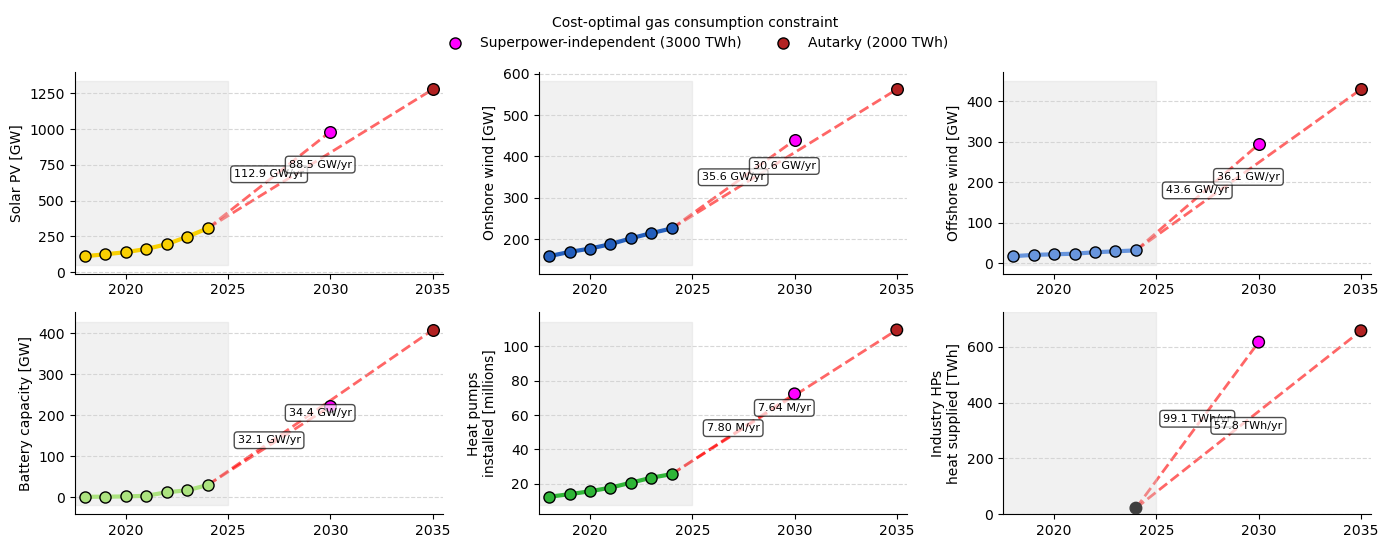

In [228]:
# total system one
years = pd.Series(range(2018, 2025)).astype(str)

# Define line kwargs for projection lines
projection_line_kwargs = {
    'linestyle': '--',
    'linewidth': 2,
    'alpha': 0.6,
    'color': 'red',
    'zorder': 0,
}

fig, axs = plt.subplots(2, 3, figsize=(14, 5))

for ax, carrier in zip(
    axs.flatten(),
    irena_carriers.keys()
):

    irena_carrier = irena_carriers[carrier]
    ss = df.loc[idx[inter, irena_carrier, :, :, years]].astype(float).groupby(level=4).sum().mul(1e-3)

    ax.plot(
        ss.index.astype(int),
        ss.values,
        color=tech_colors[carrier],
        lw=3,
        marker='o',
        markeredgecolor='black',
        markerfacecolor=tech_colors[carrier],
        markersize=8,
        markeredgewidth=1
        )
    
    model_2030 = n_2030.generators.loc[n_2030.generators.carrier.isin(pypsa_carriers[carrier]), 'p_nom_opt'].mul(1e-3).sum()
    model_2035 = n_2035.generators.loc[n_2035.generators.carrier.isin(pypsa_carriers[carrier]), 'p_nom_opt'].mul(1e-3).sum()

    ax.scatter(
        2030,
        model_2030,
        color='magenta',
        s=70,
        marker='o',
        edgecolor='black',
        label='Superpower-independent (3000TWh)' if carrier == list(irena_carriers.keys())[0] else None
        )
    ax.scatter(
        2035,
        model_2035,
        color='firebrick',
        s=70,
        marker='o',
        edgecolor='black',
        label='Autarky (2000TWh)' if carrier == list(irena_carriers.keys())[0] else None
    )

    # Add projection lines and gradient labels
    val_2024 = ss.loc['2024'].iloc[0]
    
    # Line from 2024 to 2030

    print([2024, 2030], [val_2024, model_2030])

    ax.plot([2024, 2030], [val_2024, model_2030], **projection_line_kwargs)
    gradient_2030 = (model_2030 - val_2024) / (2030 - 2024)
    ax.text(2027, (val_2024 + model_2030) / 2 + 5, f'{gradient_2030:.1f} GW/yr',
            ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    # Line from 2024 to 2035
    ax.plot([2024, 2035], [val_2024, model_2035], **projection_line_kwargs)
    gradient_2035 = (model_2035 - val_2024) / (2035 - 2024)
    ax.text(2029.5, (val_2024 + model_2035) / 2 - 5, f'{gradient_2035:.1f} GW/yr',
            ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_ylabel(irena_ylabels[carrier])

ax = axs[1,0]

ax.plot(
    bat.loc[years].index.astype(int),
    bat.loc[years].values,
    color=tech_colors['battery'],
    lw=3,
    marker='o',
    markeredgecolor='black',
    markerfacecolor=tech_colors['battery'],
    markersize=8,
    markeredgewidth=1
    )

# model_2030 = n_2030.links.loc[n_2030.links.carrier.isin(['battery discharger', 'home battery discharger']), 'p_nom_opt'].mul(1e-3).sum()
# model_2035 = n_2035.links.loc[n_2035.links.carrier.isin(['battery discharger', 'home battery discharger']), 'p_nom_opt'].mul(1e-3).sum()
model_2030 = n_2030.links.loc[n_2030.links.carrier.isin(['battery discharger']), 'p_nom_opt'].mul(1e-3).sum()
model_2035 = n_2035.links.loc[n_2035.links.carrier.isin(['battery discharger']), 'p_nom_opt'].mul(1e-3).sum()

ax.scatter(
    2030,
    model_2030,
    color='magenta',
    s=70,
    marker='o',
    edgecolor='black',
    )
ax.scatter(
    2035,
    model_2035,
    color='firebrick',
    s=70,
    marker='o',
    edgecolor='black',
)

# Add projection lines and gradient labels for battery
val_2024 = bat.loc['2024']

# Line from 2024 to 2030
ax.plot([2024, 2030], [val_2024, model_2030], **projection_line_kwargs)
gradient_2030 = (model_2030 - val_2024) / (2030 - 2024)
ax.text(2027, (val_2024 + model_2030) / 2 + 1, f'{gradient_2030:.1f} GW/yr',
        ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Line from 2024 to 2035
ax.plot([2024, 2035], [val_2024, model_2035], **projection_line_kwargs)
gradient_2035 = (model_2035 - val_2024) / (2035 - 2024)
ax.text(2029.5, (val_2024 + model_2035) / 2 - 1, f'{gradient_2035:.1f} GW/yr',
        ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax = axs[1,1]

ax.plot(
    heat_pumps_europe.loc[years].index.astype(int),
    heat_pumps_europe.loc[years].values,
    color=tech_colors['heat pump'],
    lw=3,
    marker='o',
    markeredgecolor='black',
    markerfacecolor=tech_colors['heat pump'],
    markersize=8,
    markeredgewidth=1
    )

hp_shares_2030 = get_hp_shares(n_2030, num_households.keys())
hp_shares_2035 = get_hp_shares(n_2035, num_households.keys())

model_2030 = hp_shares_2030.mul(num_households).sum()
model_2035 = hp_shares_2035.mul(num_households).sum()

ax.scatter(
    [2030, 2035],
    [model_2030, model_2035],
    color=['magenta', 'firebrick'],
    s=70,
    marker='o',
    edgecolor='black',
    )

# Add projection lines and gradient labels for heat pumps
val_2024 = heat_pumps_europe.loc['2024']

# Line from 2024 to 2030
ax.plot([2024, 2030], [val_2024, model_2030], **projection_line_kwargs)
gradient_2030 = (model_2030 - val_2024) / (2030 - 2024)
ax.text(2027, (val_2024 + model_2030) / 2 + 0.5, f'{gradient_2030:.2f} M/yr',
        ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Line from 2024 to 2035
ax.plot([2024, 2035], [val_2024, model_2035], **projection_line_kwargs)
gradient_2035 = (model_2035 - val_2024) / (2035 - 2024)
ax.text(2029.5, (val_2024 + model_2035) / 2 - 0.5, f'{gradient_2035:.2f} M/yr',
        ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))


model_2030 = get_industry_hp_supplied(n_2030)
model_2035 = get_industry_hp_supplied(n_2035)

ax = axs[1,2]

ax.scatter(
    [2024, 2030, 2035],
    [22, model_2030, model_2035],
    color=['black', 'magenta', 'firebrick'],
    s=70,
    marker='o',
    edgecolor='black',
    )
ax.set_ylim(0, max(model_2030, model_2035) * 1.1)

# Add projection lines and gradient labels for industry HPs
val_2024 = 22

# Line from 2024 to 2030
ax.plot([2024, 2030], [val_2024, model_2030], **projection_line_kwargs)
gradient_2030 = (model_2030 - val_2024) / (2030 - 2024)
ax.text(2027, (val_2024 + model_2030) / 2 + 5, f'{gradient_2030:.1f} TWh/yr',
        ha='center', va='bottom', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Line from 2024 to 2035
ax.plot([2024, 2035], [val_2024, model_2035], **projection_line_kwargs)
gradient_2035 = (model_2035 - val_2024) / (2035 - 2024)
ax.text(2029.5, (val_2024 + model_2035) / 2 - 5, f'{gradient_2035:.1f} TWh/yr',
        ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))



axs[1,0].set_ylabel('Battery capacity [GW]')
axs[1,1].set_ylabel('Heat pumps\ninstalled [millions]')
axs[1,2].set_ylabel('Industry HPs\nheat supplied [TWh]')

for ax in axs.flatten():
    ax.set_xlim(2017.5, 2035.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.fill_between(
        [2017.5, 2025],
        *ax.get_ylim(),
        color='lightgrey',
        alpha=0.3,
    )
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
for ax in axs.flatten():
    ax.set_xticks([2020, 2025, 2030, 2035])
    ax.set_xticklabels([2020, 2025, 2030, 2035])

# Add central legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='magenta', 
               markersize=8, markeredgecolor='black', label='Superpower-independent (3000 TWh)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick', 
               markersize=8, markeredgecolor='black', label='Autarky (2000 TWh)')
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.1), 
          ncol=2, frameon=False, title='Cost-optimal gas consumption constraint')

plt.savefig('independence_rollout_speed.pdf', bbox_inches='tight')
plt.show()

In [106]:
ss.index

Index(['2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='object')

In [ ]:
# country level one

fig, axs = len()